# L1: Haystack Building Blocks

In [1]:
import warnings

warnings.filterwarnings('ignore')

In [4]:
from dotenv import load_dotenv

_ = load_dotenv()

## Components

In [5]:
from haystack.components.embedders import OpenAIDocumentEmbedder

embedder = OpenAIDocumentEmbedder(model="text-embedding-3-small")

In [6]:
embedder

Inputs:
  - documents: list[Document]
Outputs:
  - documents: list[Document]
  - meta: dict[str, Any]

In [7]:
from haystack.dataclasses import Document

documents = [
    Document(content="Haystack is an opensource AI framework to build full AI applications in Python"),
    Document(content="You can build AI Pipelines by combining Components")
]

embedder.run(documents=documents)

Calculating embeddings: 1it [00:09,  9.93s/it]


{'documents': [Document(id=d3b99ddb142b46c5565a8110f10c1fab70536dd0fbd01af0f842630352172416, content: 'Haystack is an opensource AI framework to build full AI applications in Python', embedding: vector of size 1536),
  Document(id=11ee1490e1dc5cd44361b1541008891b0b40aabd4d5bb2da6a2499f23e6120f7, content: 'You can build AI Pipelines by combining Components', embedding: vector of size 1536)],
 'meta': {'model': 'text-embedding-3-small',
  'usage': {'prompt_tokens': 24, 'total_tokens': 24}}}

## Pipelines

### Initialize a Document Store

In [8]:
from haystack.document_stores.in_memory import InMemoryDocumentStore

document_store = InMemoryDocumentStore()

### Writing documents with embeddings into a document store

In [9]:
from haystack import Pipeline
from haystack.components.converters.txt import TextFileToDocument
from haystack.components.preprocessors.document_splitter import DocumentSplitter
from haystack.components.embedders import OpenAIDocumentEmbedder
from haystack.components.writers import DocumentWriter

converter = TextFileToDocument()
splitter = DocumentSplitter()
embedder = OpenAIDocumentEmbedder()
writer = DocumentWriter(document_store=document_store)

indexing_pipeline = Pipeline()

indexing_pipeline.add_component("converter", converter)
indexing_pipeline.add_component("splitter", splitter)
indexing_pipeline.add_component("embedder", embedder)
indexing_pipeline.add_component("writer", writer)

### Connecting Components

In [10]:
indexing_pipeline.connect("converter", "splitter")
indexing_pipeline.connect("splitter", "embedder")
indexing_pipeline.connect("embedder", "writer")

🚅 Components
  - converter: TextFileToDocument
  - splitter: DocumentSplitter
  - embedder: OpenAIDocumentEmbedder
  - writer: DocumentWriter
🛤️ Connections
  - converter.documents -> splitter.documents (list[Document])
  - splitter.documents -> embedder.documents (list[Document])
  - embedder.documents -> writer.documents (list[Document])

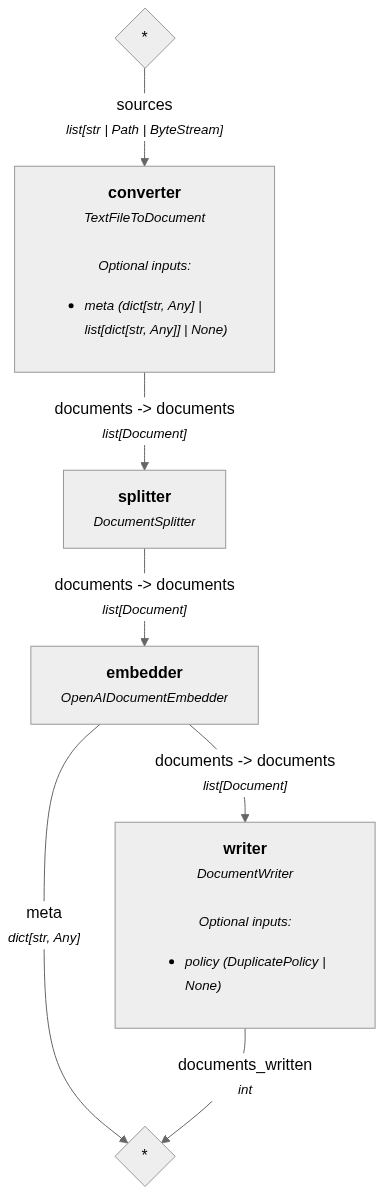

In [11]:
indexing_pipeline.show()

In [19]:
splitter

splitter
Inputs:
  - documents: list[Document]
Outputs:
  - documents: list[Document]

### Running Pipelines

In [12]:
indexing_pipeline.run({
    "converter": {
        "sources": ["data/davinci.txt"]
    }
})

Calculating embeddings: 12it [00:09,  1.27it/s]


{'embedder': {'meta': {'model': 'text-embedding-ada-002-v2',
   'usage': {'prompt_tokens': 107670, 'total_tokens': 107670}}},
 'writer': {'documents_written': 363}}

In [13]:
document_store.filter_documents()[5].content

'                      _LEONARDO DA VINCI_.\n\n                    FAITHFULLY TRANSLATED FROM THE\n\n                           ORIGINAL ITALIAN,\n\n              AND NOW FIRST DIGESTED UNDER PROPER HEADS,\n\n                   /By/ JOHN FRANCIS RIGAUD, /Esq./\n\n      ACADEMICIAN OF THE ROYAL ACADEMY OF PAINTING AT LONDON, AND\n       ALSO OF THE ACADEMIA CLEMENTINA AT BOLOGNA, AND THE ROYAL\n                         ACADEMY AT STOCKHOLM.\n\n    Illustrated with twenty-three Copper-plates, and other Figures.\n\n              '

### Creating a document search pipeline

In [14]:
from haystack.components.embedders import OpenAITextEmbedder
from haystack.components.retrievers.in_memory import InMemoryEmbeddingRetriever

query_embedder = OpenAITextEmbedder()
retriever = InMemoryEmbeddingRetriever(document_store=document_store)

document_search = Pipeline()

document_search.add_component("query_embedder", query_embedder)
document_search.add_component("retriever", retriever)

document_search.connect("query_embedder.embedding", "retriever.query_embedding")

🚅 Components
  - query_embedder: OpenAITextEmbedder
  - retriever: InMemoryEmbeddingRetriever
🛤️ Connections
  - query_embedder.embedding -> retriever.query_embedding (list[float])

In [20]:
query_embedder

query_embedder
Inputs:
  - text: str
Outputs:
  - embedding: list[float]
  - meta: dict[str, Any]

In [21]:
retriever

retriever
Inputs:
  - query_embedding: list[float]
  - filters: dict[str, Any] | None
  - top_k: int | None
  - scale_score: bool | None
  - return_embedding: bool | None
Outputs:
  - documents: list[Document]

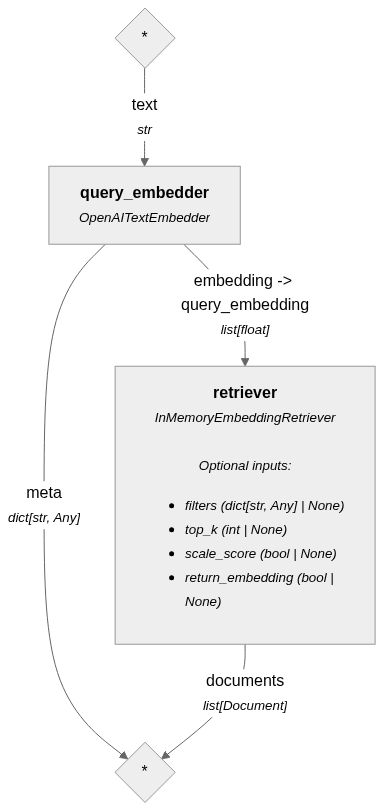

In [15]:
document_search.show()

In [16]:
question = "Howl old was Davinci when he died?"

results = document_search.run({
    "query_embedder": {
        "text": question
    }
})

for i, document in enumerate(results["retriever"]["documents"]):
    print("\n--------------------\n")
    print(f"DOCUMENT {i}")
    print(document.content)


--------------------

DOCUMENT 0
witness either to the
almost annihilation of the colours in Leonardo's famous picture of the
Last Supper, owing to the damp of the wall, or to the peeling of the
colours from the wall in the council-chamber at Florence, he probably
would have spared this ill-natured reflection. If it applied at all,
it could only be to a very small part of the pursuit in which Leonardo
was occupied, namely, preparing varnish; and if age were necessary
to give the varnish strength, or it were the better for keeping, the
answer was in an equal degree both silly and impertinent; and it is no
wonder it should disgust such a mind as Leonardo's, or produce, as we
find it did, such a breach between the Pope and him, that the intended
pictures, whatever they might have been, were never begun.

Disgusted with his treatment at Rome, where the former antipathy
between him and Michael Angelo was again revived by the partisans of
each, he the next year quitted it; and accepting an 

In [17]:
question = "How old was Davinci when he died?"

results = document_search.run({
    "query_embedder": {
        "text": question
    },
    "retriever": {"top_k": 3}
})

for i, document in enumerate(results["retriever"]["documents"]):
    print("\n" + "-" * 20 + "\n")
    print(f"DOCUMENT {i}")
    print(document.content)


--------------------

DOCUMENT 0
witness either to the
almost annihilation of the colours in Leonardo's famous picture of the
Last Supper, owing to the damp of the wall, or to the peeling of the
colours from the wall in the council-chamber at Florence, he probably
would have spared this ill-natured reflection. If it applied at all,
it could only be to a very small part of the pursuit in which Leonardo
was occupied, namely, preparing varnish; and if age were necessary
to give the varnish strength, or it were the better for keeping, the
answer was in an equal degree both silly and impertinent; and it is no
wonder it should disgust such a mind as Leonardo's, or produce, as we
find it did, such a breach between the Pope and him, that the intended
pictures, whatever they might have been, were never begun.

Disgusted with his treatment at Rome, where the former antipathy
between him and Michael Angelo was again revived by the partisans of
each, he the next year quitted it; and accepting an 